In [5]:
#Section 1: Data Loading and Exploration 
#Loading and examining the SOA 2009-2013 Individual LIfe Mortality Experience Study
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
import warnings
warnings.filterwarnings('ignore')

#Display settings 
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.6f' % x)
print("Libraries loaded successfully")

Libraries loaded successfully


In [6]:
# Load the cleaned term mortalitty data 
df = pd.read_excel('../data/term_mortality_data_clean.xlsx')

#Look at data 
print(f"Dataset shape: {df.shape[0]:,} rows and {df.shape[1]} columns")
print(f"\nColumn names:")
for col in df.columns:
    print(f" - {col}")

Dataset shape: 415,598 rows and 32 columns

Column names:
 - Source_Name
 - Observation Year
 - Common_Company_Indicator
 - Gender
 - Smoker Status
 - Insurance Plan
 - Issue Age
 - Duration
 - Face Amount Band
 - Preferred Indicator
 - Attained Age
 - Issue Year
 - Number_Of_Preferred_Classes
 - Preferred_Class
 - SOA Anticipated Level Term Period
 - SOA Guaranteed Level Term Period
 - SOA Post Level Term Indicator
 - Select_Ultimate_Indicator
 - Number of Deaths
 - Death Claim Amount
 - Policies Exposed
 - Amount Exposed
 - Expected Death QX7580E by Amount
 - Expected Death QX2001VBT by Amount
 - Expected Death QX2008VBT by Amount
 - Expected Death QX2008VBTLU by Amount
 - Expected Death QX2015VBT by Amount
 - Expected Death QX7580E by Policy
 - Expected Death QX2001VBT by Policy
 - Expected Death QX2008VBT by Policy
 - Expected Death QX2008VBTLU by Policy
 - Expected Death QX2015VBT by Policy


In [11]:
#Basic Data Exploration 
print("Basic Statistics for key columns:")
print(f"\nAttained Age Range: {df['Attained Age'].min()} to {df['Attained Age'].max()}")
print(f"Total Policies Exposed: {df['Policies Exposed'].sum():,.0f}")
print(f"Total Actual Deaths: {df['Number of Deaths'].sum():,.0f}")
print(f"Overall Mortality Rate: {df['Number of Deaths'].sum()/df['Policies Exposed'].sum():.6f}")
print(f"\nObservation Years in Dataset: {sorted(df['Observation Year'].unique())}")
print(f"\nInsurance Plans in Dataset:{df['Insurance Plan'].unique()}")
print(f"\nSmokerStatus Values: {df['Smoker Status'].unique()}")



Basic Statistics for key columns:

Attained Age Range: 18 to 97
Total Policies Exposed: 10,063,695
Total Actual Deaths: 20,817
Overall Mortality Rate: 0.002069

Observation Years in Dataset: [np.int64(2003), np.int64(2004)]

Insurance Plans in Dataset:[' Term' ' VL']

SmokerStatus Values: ['Nonsmoker']


In [7]:
#Filter to Term Insurance Only
df=df[df['Insurance Plan']==' Term']

print(f"Rows after filtering to Term only: {df.shape[0]:,}")
print(f"Insurance plans remaining:{df['Insurance Plan'].unique()}")

Rows after filtering to Term only: 339,306
Insurance plans remaining:[' Term']


In [8]:
#Rename columns for easier reference in code
df=df.rename(columns={
    'Attained Age':'attained_age',
    'Number of Deaths': 'actual_deaths',
    'Policies Exposed': 'policies_exposed',
    'Expected Death QX2015VBT by Policy': 'expected_deaths_2015vbt'
})

print("Columns renamed successfully")
print(f"\nKey columns confirmed:")
print(f" - attained_age:{df['attained_age'].dtype}")
print(f" - actual_deaths:{df['actual_deaths'].dtype}")
print(f" - policies_exposed: {df['policies_exposed'].dtype}")
print(f" - expected_deaths_2015vbt:{df['expected_deaths_2015vbt'].dtype}")


Columns renamed successfully

Key columns confirmed:
 - attained_age:int64
 - actual_deaths:int64
 - policies_exposed: float64
 - expected_deaths_2015vbt:float64


In [11]:
#Section 2: A/E Mortality Analysis 
#Grouping data by attained age to calculate actual vs expected mortality 

ae_table = df.groupby('attained_age').agg(
    actual_deaths=('actual_deaths','sum'),
    policies_exposed=('policies_exposed','sum'),
    expected_deaths=('expected_deaths_2015vbt','sum')
).reset_index()
#Filter to relevant age range for term life pricing 
ae_table=ae_table[ae_table['attained_age'].between(25,75)]

print(f"Age range after filtering:{ae_table['attained_age'].min()} to {ae_table['attained_age'].max()}")
print(f"Number of age groups:{len(ae_table)}")

#Calculate actual qx, expected qx and A/E ratio
ae_table['actual_qx']=ae_table['actual_deaths']/ae_table['policies_exposed']
ae_table['expected_qx']=ae_table['expected_deaths']/ae_table['policies_exposed']
ae_table['ae_ratio']=ae_table['actual_qx']/ae_table['expected_qx']

print(f"A/E table created with {len(ae_table)} age groups")
print(f"\nSample output:")
print(ae_table[ae_table['attained_age'].between(35, 45)].to_string(index=False))



Age range after filtering:25 to 75
Number of age groups:51
A/E table created with 51 age groups

Sample output:
 attained_age  actual_deaths  policies_exposed  expected_deaths  actual_qx  expected_qx  ae_ratio
           35             69     225869.901900        53.529230   0.000305     0.000237  1.289015
           36             89     241317.149500        64.357420   0.000369     0.000267  1.382902
           37            115     260265.545600        78.221860   0.000442     0.000301  1.470177
           38            129     279762.327300        94.464160   0.000461     0.000338  1.365597
           39            137     292790.824100       109.737430   0.000468     0.000375  1.248435
           40            176     301428.085300       125.043530   0.000584     0.000415  1.407510
           41            144     307510.270700       140.287920   0.000468     0.000456  1.026460
           42            178     304767.987800       151.027580   0.000584     0.000496  1.178593
      

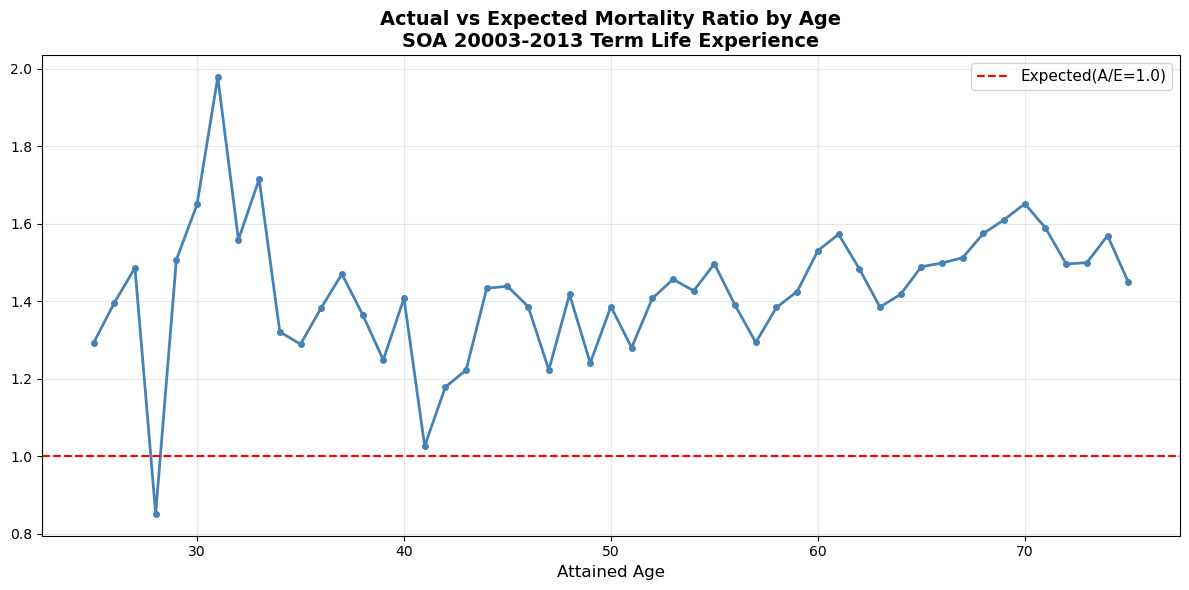

Chart 1 saved successfully


In [12]:
#Section 3:Visualizations 
#Chart 1 - A/E Ratio by Attained Age 

fig,ax=plt.subplots(figsize=(12,6))
ax.plot(ae_table['attained_age'], ae_table['ae_ratio'],
        color='steelblue',linewidth=2,marker='o',markersize=4)

ax.axhline(y=1.0,color='red', linestyle='--',linewidth=1.5,label='Expected(A/E=1.0)')
ax.set_title('Actual vs Expected Mortality Ratio by Age\nSOA 20003-2013 Term Life Experience',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Attained Age',fontsize=12)
ax.legend(fontsize=11)
ax.grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig('../data/ae_ratio_chart.png',dpi=150)
plt.show()

print("Chart 1 saved successfully")


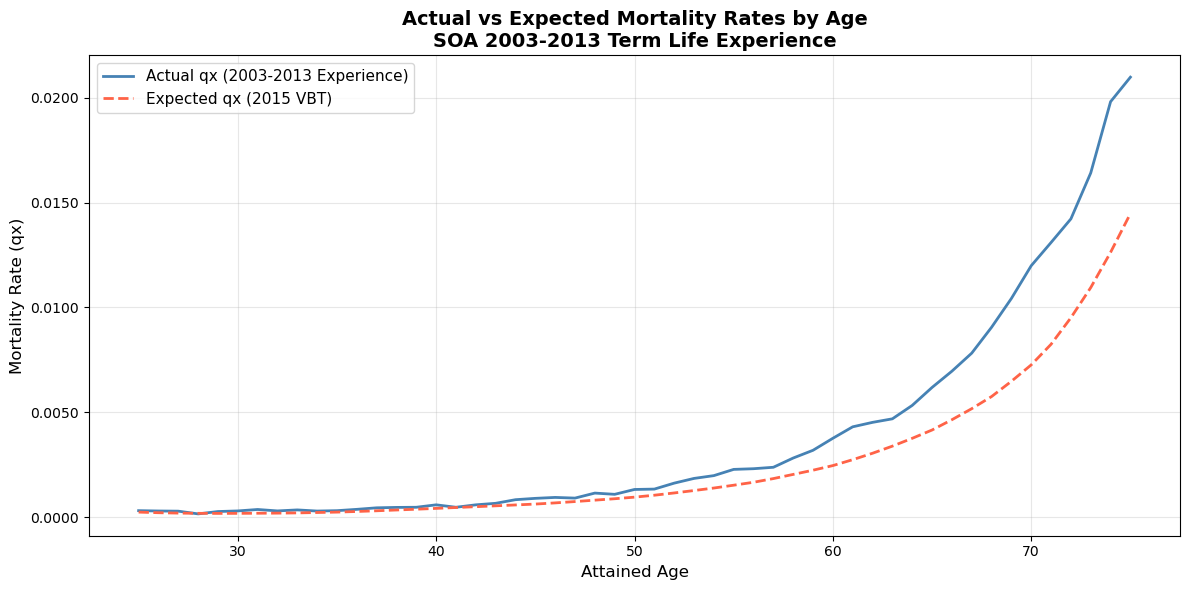

Chart 2 saved successfully


In [16]:
#Chart 2- Actual vs Expected Mortality Rates by Age 

fig,ax=plt.subplots(figsize=(12,6))

ax.plot(ae_table['attained_age'], ae_table['actual_qx'],
        color='steelblue',linewidth=2,label='Actual qx (2003-2013 Experience)')

ax.plot(ae_table['attained_age'], ae_table['expected_qx'],
        color='tomato', linewidth=2, linestyle='--',label='Expected qx (2015 VBT)')

ax.set_title('Actual vs Expected Mortality Rates by Age\nSOA 2003-2013 Term Life Experience',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Attained Age',fontsize=12)
ax.set_ylabel('Mortality Rate (qx)',fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

plt.tight_layout()
plt.savefig('../data/actual_vs_expected_qx.png',dpi=150)
plt.show()

print("Chart 2 saved successfully") 





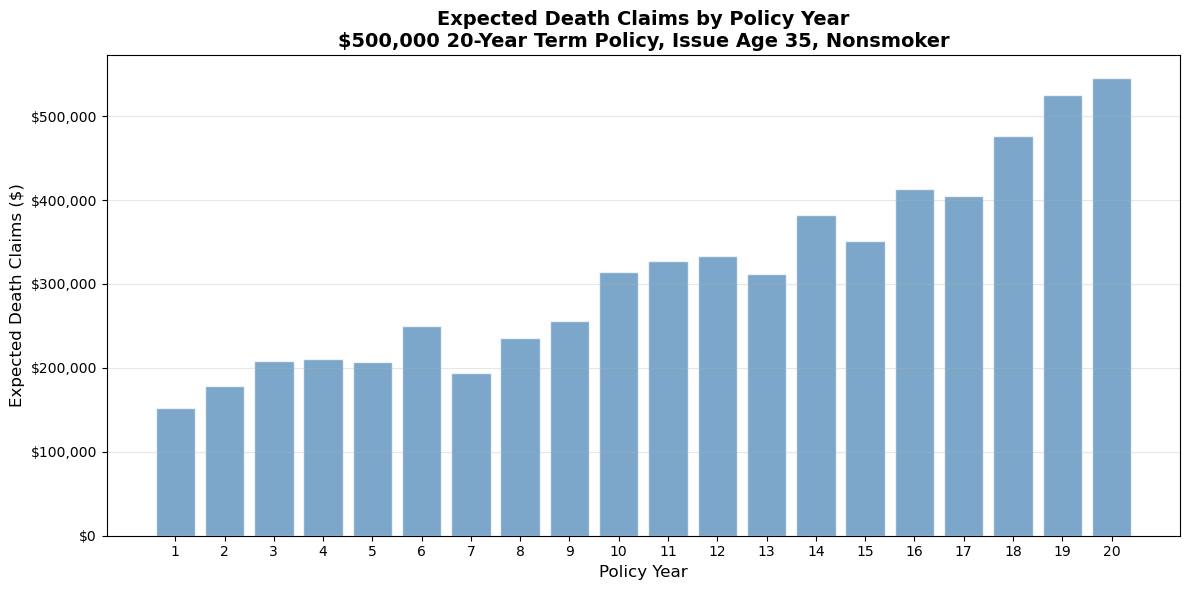

Chart 3 saved successfully


In [18]:
#Chart 3 - Death Claims Projection Over Policy Term 
#Set up policy Assumptions 

issue_age = 35 
term=20
face_amount=500000
lapse_rate=0.03
interest_rate=0.05

#Build the Projection Table 
ages=list(range(issue_age, issue_age+term))
survivors = [1000]
for i in range(1,term):
    qx=ae_table.loc[ae_table['attained_age']==ages[i-1],'actual_qx'].values[0]
    next_survivors =survivors [-1]*(1-qx)*(1-lapse_rate)
    survivors.append(next_survivors)
    

deaths =[]
for i in range(term):
    qx=ae_table.loc[ae_table['attained_age']==ages[i],'actual_qx'].values[0]
    deaths.append(survivors[i]*qx)

death_claims=[d*face_amount for d in deaths]
policy_years=list(range(1, term+1))

#Plot 
fig, ax = plt.subplots(figsize=(12,6))

ax.bar(policy_years, death_claims, color='steelblue',alpha=0.7, edgecolor='white')
ax.set_title('Expected Death Claims by Policy Year\n$500,000 20-Year Term Policy, Issue Age 35, Nonsmoker',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Policy Year', fontsize=12)
ax.set_ylabel('Expected Death Claims ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.set_xticks(policy_years)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/death_claims_projection.png', dpi=150)
plt.show()

print("Chart 3 saved successfully")
    

In [23]:
# Section 4: Premium Pricing Model
# Reproducing the actuarial equivalence principle in Python

# Assumptions
issue_age = 35
term = 20
face_amount = 500000
lapse_rate = 0.03
interest_rate = 0.05
expense_loading = 0.15
profit_margin = 0.10

# Build projection table as a DataFrame
policy_years = list(range(1, term + 1))
ages = list(range(issue_age, issue_age + term))

# Survivors
survivors = [1000]
for i in range(1, term):
    qx = ae_table.loc[ae_table['attained_age'] == ages[i-1], 'actual_qx'].values[0]
    next_survivors = survivors[-1] * (1 - qx) * (1 - lapse_rate)
    survivors.append(next_survivors)

# Deaths
deaths = []
for i in range(term):
    qx = ae_table.loc[ae_table['attained_age'] == ages[i], 'actual_qx'].values[0]
    deaths.append(survivors[i] * qx)

# Discount factors
discount_factors = [1 / (1 + interest_rate) ** t for t in policy_years]

# Death claims
death_claims = [d * face_amount for d in deaths]

# Present value of claims
pv_claims = [death_claims[i] * discount_factors[i] for i in range(term)]

# Build DataFrame
projection = pd.DataFrame({
    'policy_year': policy_years,
    'attained_age': ages,
    'survivors': survivors,
    'deaths': deaths,
    'death_claims': death_claims,
    'discount_factor': discount_factors,
    'pv_claims': pv_claims
})

# Calculate net premium using equivalence principle
total_pv_claims = sum(pv_claims)

# Present value of an annuity due (premium income)
pv_annuity = sum([survivors[i] * discount_factors[i] for i in range(term)])

# Net premium
net_premium = total_pv_claims / pv_annuity

# Gross premium
gross_premium = net_premium / (1 - expense_loading - profit_margin)

print(f"Total PV of Claims: ${total_pv_claims:,.2f}")
print(f"PV Annuity Factor: {pv_annuity:,.4f}")
print(f"\nNet Annual Premium: ${net_premium:,.2f}")
print(f"Gross Annual Premium: ${gross_premium:,.2f}")
print(f"Monthly Premium: ${gross_premium/12:,.2f}")

Total PV of Claims: $3,545,489.30
PV Annuity Factor: 9,898.4329

Net Annual Premium: $358.19
Gross Annual Premium: $477.58
Monthly Premium: $39.80


In [24]:
#Sensitivity Analysis 
#How does the gross premium change across different issue ages and interest rates?

def calculate_premium(issue_age, interest_rate, term=20, face_amount=500000,
                      lapse_rate=0.03, expense_loading=0.15, profit_margin=0.1):
    ages=list(range(issue_age, issue_age+term))

    #Check all ages exist in ae_table
    available_ages = ae_table['attained_age'].tolist()
    if not all(age in available_ages for age in ages):
        return None 
   
    # Survivors
    survivors = [1000]
    for i in range(1, term):
        qx = ae_table.loc[ae_table['attained_age'] == ages[i-1], 'actual_qx'].values[0]
        survivors.append(survivors[-1] * (1 - qx) * (1 - lapse_rate))
    
    # Deaths, claims, discount factors
    deaths = [survivors[i] * ae_table.loc[ae_table['attained_age'] == ages[i], 'actual_qx'].values[0] for i in range(term)]
    discount_factors = [1 / (1 + interest_rate) ** t for t in range(1, term + 1)]
    death_claims = [d * face_amount for d in deaths]
    
    # PV calculations
    total_pv_claims = sum([death_claims[i] * discount_factors[i] for i in range(term)])
    pv_annuity = sum([survivors[i] * discount_factors[i] for i in range(term)])
    
    net_premium = total_pv_claims / pv_annuity
    gross_premium = net_premium / (1 - expense_loading - profit_margin)
    
    return round(gross_premium, 2)

print("Premium calculation function defined successfully")


Premium calculation function defined successfully


In [25]:
#Build the sensititvity grid 
issue_ages = [25, 30, 35, 40, 45, 50, 55]
interest_rates = [0.03, 0.04, 0.05, 0.06, 0.07]

#Calculate premium for every combination 
results ={}
for age in issue_ages:
    results[age]={}
    for rate in interest_rates:
        premium=calculate_premium(age, rate)
        results[age][rate]=premium 

# Convert to DataFrame for clean display
sensitivity_table = pd.DataFrame(results).T
sensitivity_table.columns = [f'{int(r*100)}% Interest' for r in interest_rates]
sensitivity_table.index.name = 'Issue Age'

print("Sensitivity Analysis - Gross Annual Premium ($)")
print("=" * 60)
print(sensitivity_table.to_string())

Sensitivity Analysis - Gross Annual Premium ($)
           3% Interest  4% Interest  5% Interest  6% Interest  7% Interest
Issue Age                                                                 
25          239.240000   235.270000   231.540000   228.030000   224.760000
30          334.460000   326.550000   319.040000   311.940000   305.240000
35          505.830000   491.360000   477.580000   464.480000   452.060000
40          804.160000   780.540000   758.030000   736.640000   716.340000
45         1324.770000  1283.970000  1245.160000  1208.340000  1173.490000
50         2242.820000  2168.380000  2097.720000  2030.800000  1967.570000
55         3931.070000  3790.790000  3657.860000  3532.200000  3413.690000


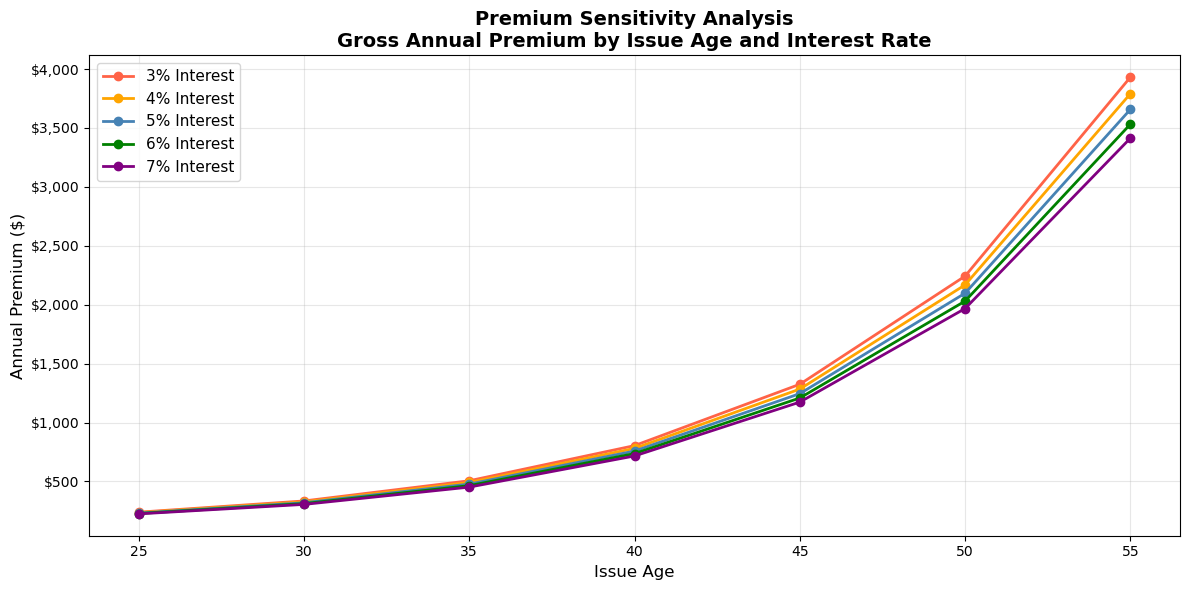

Sensitivity chart saved successfully


In [26]:
# Visualize the sensitivity analysis
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['tomato', 'orange', 'steelblue', 'green', 'purple']

for i, rate in enumerate(interest_rates):
    col = f'{int(rate*100)}% Interest'
    ax.plot(issue_ages, sensitivity_table[col], 
            marker='o', linewidth=2, 
            color=colors[i], label=col)

ax.set_title('Premium Sensitivity Analysis\nGross Annual Premium by Issue Age and Interest Rate',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Issue Age', fontsize=12)
ax.set_ylabel('Annual Premium ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(issue_ages)

plt.tight_layout()
plt.savefig('../data/sensitivity_analysis.png', dpi=150)
plt.show()

print("Sensitivity chart saved successfully")